In [4]:
#load the data set
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay



In [5]:
df=pd.read_csv("NBUser data.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


## split the features and label

In [6]:
 x=df[['EstimatedSalary','Age']]
 y=df[['Purchased']]

In [7]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [23]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)
model=GaussianNB()
model.fit(x_train,y_train)
GaussianNB()

C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,priors,None
,var_smoothing,1e-09


In [13]:
from sklearn.metrics import accuracy_score,classification_report
y_pred = model.predict(x_test)
print("\n accuracy:",accuracy_score(y_test, y_pred))
print("\n classification_report:\n",classification_report(y_test, y_pred))


 accuracy: 0.925

 classification_report:
               precision    recall  f1-score   support

           0       0.90      0.99      0.94        73
           1       0.97      0.83      0.90        47

    accuracy                           0.93       120
   macro avg       0.94      0.91      0.92       120
weighted avg       0.93      0.93      0.92       120



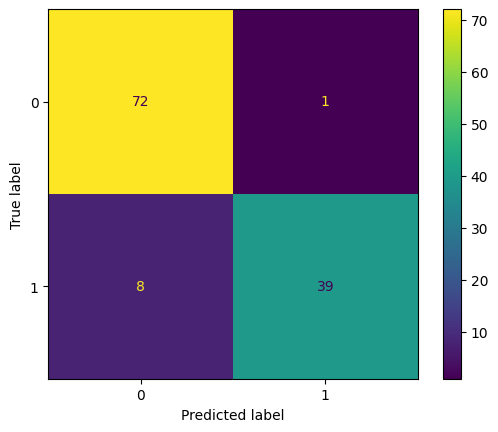

In [16]:
import matplotlib.pyplot as plt
cm=confusion_matrix(y_test,y_pred,labels=model.classes_)
cm
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


Accuracy: 0.6


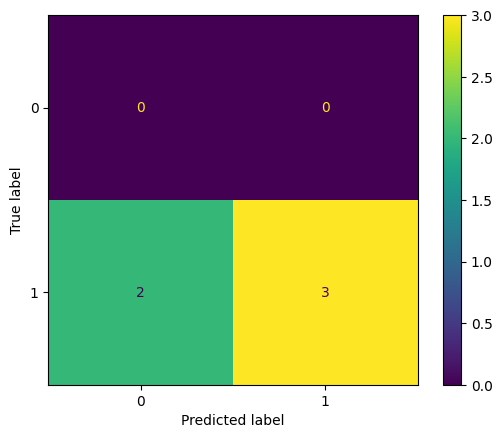

In [27]:
#tennis dataset

import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Load tennis dataset
df = pd.read_csv("tennis.csv")

# Features: outlook, temp, humidity, wind
X = pd.get_dummies(df[['outlook','temp','humidity','wind']])

# Target column (your CSV has 'tennis' instead of 'play')
y = df['tennis?']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Train Naive Bayes
model = GaussianNB()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()


In [28]:
#Import libraries
import pandas as pd
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay


In [30]:
#Load dataset
# Load tennis.csv
df = pd.read_csv("tennis.csv")

# Features and target
X = df[['outlook','temp','humidity','wind']]
y = df['tennis?']   # target column is 'tennis'


In [31]:
#Encode categorical features
# Convert categorical features into numeric codes
encoder = OrdinalEncoder()
X_encoded = encoder.fit_transform(X)


In [32]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=0
)


In [33]:
#Train Naive Bayes
model = CategoricalNB()
model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None
,min_categories,None


In [34]:
#Predictions
y_pred = model.predict(X_test)


Accuracy: 0.6


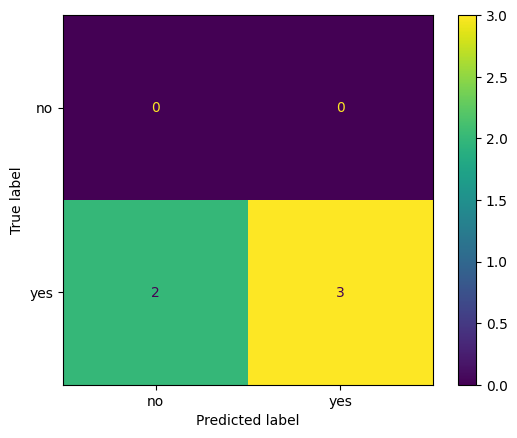

In [35]:
#Accuracy and Confusion Matrix
print("Accuracy:", accuracy_score(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred, labels=y.unique())
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=y.unique())
disp.plot()


In [40]:
#Functions for prior & conditional probability
def prior_prob(df, label):
    total = len(df)
    count = (df['tennis?'] == label).sum()
    return count / total

def conditional_prob(df, feature, value, label):
    subset = df[df['tennis?'] == label]
    return (subset[feature] == value).sum() / len(subset) if len(subset) > 0 else 0


In [43]:
#User input for class and test instance
# Example test instance
test_instance = {"outlook":"sunny","temp":"cool","humidity":"normal","wind":"strong"}

# User chooses which class to evaluate
chosen_class = input("Enter class to calculate (yes/no): ").strip().lower()

#Calculate probabilities
prior = prior_prob(df, chosen_class)
print(f"\nPrior P({chosen_class}) = {prior:.3f}")

combined = prior
for feature, value in test_instance.items():
    cond = conditional_prob(df, feature, value, chosen_class)
    print(f"P({feature}={value} | {chosen_class}) = {cond:.3f}")
    combined *= cond

print(f"\nCombined probability (unnormalized) for class={chosen_class} = {combined:.6f}")



Enter class to calculate (yes/no):  yes



Prior P(yes) = 0.643
P(outlook=sunny | yes) = 0.222
P(temp=cool | yes) = 0.333
P(humidity=normal | yes) = 0.667
P(wind=strong | yes) = 0.333

Combined probability (unnormalized) for class=yes = 0.010582
